# IMDB TOP 1000 MOVIES
#### Goal of this notebook: To explore imdb top 1000 movies and answer some questions about the dataset
#### Toll used: Pandas,Numpy,Matplotlib

## 1. Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib .pyplot as plt

## 2. Loading dataset

In [2]:
data=pd.read_csv('imdb_top_1000.csv')

## 3. Inspecting data

In [3]:
data.head() 
#data.head() shows the starting entries of data

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [4]:
data.shape
#data.shape() shows the number of columns and rows dataset consists

(1000, 16)

In [5]:
data.info()
#data.info() It shows the columns name,How much null values are present in column, data type of the column,memory used

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB


## 4. Cleanning Data

In [6]:
data.isna().sum()
#Here we are checking which columns contain null values Here we can see Certificate,Meta score,Gross contain null values

Poster_Link        0
Series_Title       0
Released_Year      0
Certificate      101
Runtime            0
Genre              0
IMDB_Rating        0
Overview           0
Meta_score       157
Director           0
Star1              0
Star2              0
Star3              0
Star4              0
No_of_Votes        0
Gross            169
dtype: int64

In [7]:
data.isna().sum()/len(data)*100
#This gives the percentage of null values per column 

Poster_Link       0.0
Series_Title      0.0
Released_Year     0.0
Certificate      10.1
Runtime           0.0
Genre             0.0
IMDB_Rating       0.0
Overview          0.0
Meta_score       15.7
Director          0.0
Star1             0.0
Star2             0.0
Star3             0.0
Star4             0.0
No_of_Votes       0.0
Gross            16.9
dtype: float64

In [8]:
data['Gross']=data['Gross'].str.replace(',','').astype(float)

### Purpose of this operation 
    Here, we remove commas (,) from the 'Gross' column because it contains numeric data that is currently defined as an object in the dataset. 
    Due to this, we cannot perform mathematical operations on it. Therefore, we convert the gross collection numbers containing commas into floats.
    Because our column also contains NaN values (null values), we cannot convert it into integers, so we convert it into floats.

In [9]:
data['Runtime']=data['Runtime'].str.replace('min','').astype(int)

### Purpose of this operation
    We convert 'Runtime' into an integer data type. Because it contains the string 'min' alongside the numbers, 
    we remove 'min' from the column and keep only the integers to perform statistical and mathematical operations on them.

# Filling the missing values

In [10]:
data['Certificate'].dtype

dtype('O')

In [11]:
missing_Certificate=data['Certificate'].isna().sum()
print(f'The number of missing values in column is {missing_Certificate}')

The number of missing values in column is 101


In [12]:
data['Certificate']=data['Certificate'].fillna('Un-Rated')
data['Certificate'].isna().sum()

np.int64(0)

## Purpose
    The 'Certificate' column includes ratings like 'A', 'U', and 'UA'. However, some movies are unrated. 
    Instead of filling these missing values with the mode of the column—which might assign an incorrect certificate 
    we created a new category called 'Un-Rated'. This gives the unrated movies a clear indication instead of leaving them as NaN values.

In [13]:
data['Meta_score'].dtype

dtype('float64')

In [14]:
missing_Meta_score=data['Meta_score'].isna().sum()
print(f'The number of null values in column Meta_score is {missing_Meta_score}')

The number of null values in column Meta_score is 157


In [15]:
median_Meta_score=data['Meta_score'].median()
print(f'The median of the Meta_score column is {median_Meta_score}')

The median of the Meta_score column is 79.0


In [16]:
data['Meta_score']=data['Meta_score'].fillna(median_Meta_score)

In [17]:
data['Meta_score'].isna().sum()

np.int64(0)

## Purpose
    Since this is numerical data, the null values can be filled with the median of the data. 
    Because the median is not affected by extreme values (outliers), we calculate the median of the 'Meta score' column 
    and use it to fill the missing entries, thereby removing all null values from the column.

### Why We Leave Null Values in the 'Gross' Column Unfilled
    We are not filling the null values in the 'Gross' collection column because movie earnings are highly unpredictable.
    We cannot determine gross collection simply by calculating the mean or median; instead, 
    it depends entirely on factors like the star cast, the director, the era, and the competition. 
    Therefore, we have decided to leave these null values as they are.

## Director Impact on Gross & Votes

In [18]:
gross_collection_director=data.groupby('Director').agg(Total_gross=('Gross','sum'),Average_gross=('Gross','mean'),Total_votes=('No_of_Votes','sum'),Movie_count=('Series_Title','count'))


### Explanation of code
    Here, we use groupby() and agg(). The groupby() function groups the data into separate tables based on a specified column, while agg() performs    mathematical operations on the designated columns. Taking the example above, we group by 'Director' and aggregate by 'Gross' and 'No_of_Votes'. This calculates the metrics for each director, such as their total gross collection and total number of votes.

### Analysis of the gross of a movie vs directors

In [44]:
print("--- Top 5 Directors by Total Box Office Gross ---")
sorted_directors=gross_collection_director.sort_values(by='Total_gross',ascending=False)
top_gross_director=sorted_directors[['Total_gross']].head(5)
print(top_gross_director)

--- Top 5 Directors by Total Box Office Gross ---
                    Total_gross
Director                       
Steven Spielberg   2.478133e+09
Anthony Russo      2.205039e+09
Christopher Nolan  1.937454e+09
James Cameron      1.748237e+09
Peter Jackson      1.597312e+09


### Analysis of the No_of_votes of a movie vs different director

In [45]:
print("--- Top 5 Directors by Total community votes ---")
sorted_votes=gross_collection_director.sort_values(by='Total_votes',ascending=False)
top_voted_directors=sorted_votes[['Total_votes']].head(5)
print(top_voted_directors)

--- Top 5 Directors by Total community votes ---
                   Total_votes
Director                      
Christopher Nolan     11578345
Quentin Tarantino      8123208
Steven Spielberg       7817166
David Fincher          6607859
Martin Scorsese        6513530


## Star Impact on Gross & Votes

In [21]:
gross_collection_stars=data.groupby('Star1').agg(total_collection=('Gross','sum'),average_collection=('Gross','mean'),vote_actors=('No_of_Votes','count'))
print(gross_collection_stars.columns)

Index(['total_collection', 'average_collection', 'vote_actors'], dtype='object')


### Analysis of the gross of a movie vs different stars

In [22]:
print("--- Top 5 Stars by Total Box Office Gross ---")
sort_collection_stars=gross_collection_stars.sort_values(by='total_collection',ascending=False)
gross_collection_actor=sort_collection_stars[['total_collection']].head(5)
print(gross_collection_actor)

--- Top 5 Stars by Total Box Office Gross ---
                   total_collection
Star1                              
Tom Hanks              2.493097e+09
Joe Russo              2.205039e+09
Leonardo DiCaprio      1.877322e+09
Daniel Radcliffe       1.835901e+09
Christian Bale         1.351591e+09


### Analysis of the No_of_votes of a movie vs different stars

In [23]:
print("--- Top 5 Stars by Total community votes ---")
sort_vote_star = gross_collection_stars.sort_values(by='vote_actors', ascending=False)
vote_star=sort_vote_star[['vote_actors']].head(5)
print(vote_star)

--- Top 5 Stars by Total community votes ---
                   vote_actors
Star1                         
Tom Hanks                   12
Robert De Niro              11
Clint Eastwood              10
Al Pacino                   10
Leonardo DiCaprio            9


### Most common IMDB rating

In [24]:
imdb_rating=data['IMDB_Rating'].value_counts()
most_common_votes=imdb_rating.head(5)
print("--- Top 5 Most Common IMDB Scores in the Dataset ---")
print(most_common_votes)

--- Top 5 Most Common IMDB Scores in the Dataset ---
IMDB_Rating
7.7    157
7.8    151
8.0    141
8.1    127
7.6    123
Name: count, dtype: int64


### Most IMDB rated movies 

In [25]:
top_rated_movies=data.sort_values(by='IMDB_Rating',ascending=False)
top_10_movies=top_rated_movies[['Series_Title','IMDB_Rating']].head(10)
print("--- Top 10 Most IMDB rated movies ---")
print(top_10_movies)

--- Top 10 Most IMDB rated movies ---
                                         Series_Title  IMDB_Rating
0                            The Shawshank Redemption          9.3
1                                       The Godfather          9.2
2                                     The Dark Knight          9.0
3                              The Godfather: Part II          9.0
4                                        12 Angry Men          9.0
5       The Lord of the Rings: The Return of the King          8.9
6                                        Pulp Fiction          8.9
7                                    Schindler's List          8.9
10  The Lord of the Rings: The Fellowship of the Ring          8.8
11                                       Forrest Gump          8.8


In [26]:
explode_data=data.copy()

In [27]:
explode_data['Genre']=explode_data['Genre'].str.split(', ')

In [28]:
explode_data=explode_data.explode('Genre')

In [29]:
genere_count=explode_data['Genre'].value_counts()
print(genere_count)

Genre
Drama        724
Comedy       233
Crime        209
Adventure    196
Action       189
Thriller     137
Romance      125
Biography    109
Mystery       99
Animation     82
Sci-Fi        67
Fantasy       66
History       56
Family        56
War           51
Music         35
Horror        32
Western       20
Film-Noir     19
Sport         19
Musical       17
Name: count, dtype: int64


### Purpose
    Here, we use the explode() function to give every genre a unique identity. For example, if a movie belongs to two genres—such as Action and Romance—the explode() function creates two separate rows for that single movie. One row will contain 'Action' and the other will contain 'Romance', allowing us to analyze each genre individually.


### Which Actor Prefers Which Genre More?

In [46]:
star_genre=pd.crosstab(explode_data['Star1'],explode_data['Genre'])

## Filmography of Aamir Khan

In [43]:
print("--- Amir khan Career Genre Preferences ---")
amir_preference=star_genre_count.loc[['Aamir Khan']]
print(amir_preference)

--- Amir khan Career Genre Preferences ---
Genre       Action  Adventure  Animation  Biography  Comedy  Crime  Drama  \
Star1                                                                       
Aamir Khan       2          1          0          1       5      1      6   

Genre       Family  Fantasy  Film-Noir  ...  Horror  Music  Musical  Mystery  \
Star1                                   ...                                    
Aamir Khan       0        0          0  ...       0      0        2        0   

Genre       Romance  Sci-Fi  Sport  Thriller  War  Western  
Star1                                                       
Aamir Khan        2       0      0         0    0        0  

[1 rows x 21 columns]


### Purpose
Here, we use pd.crosstab(), which acts as an organizer that extracts all unique values from two columns and computes their frequency counts into a structured 2D table (cross-tabulation).

### Top Actors in the Action Genre 

In [32]:
actor_genre_preferance=explode_data.groupby(['Star1','Genre']).size().reset_index(name='Movie')
action_movies=actor_genre_preferance[actor_genre_preferance['Genre']=='Action']
sorted_action_movies=action_movies.sort_values(by='Movie',ascending=False).head()
print("--- Top Actors in the Action Genre ---")
print(sorted_action_movies)

--- Top Actors in the Action Genre ---
               Star1   Genre  Movie
743    Harrison Ford  Action      5
962        Joe Russo  Action      4
1847      Tom Cruise  Action      4
378   Christian Bale  Action      4
1268     Mark Hamill  Action      3


#### Purpose
    Here, we use reset_index() to convert our grouped data back into a standard, flat 2D DataFrame by turning the index back into regular columns. We use size() to count the number of movies within each group. While shape provides the total number of rows across the entire dataset, size() allows us to calculate the specific movie count for each individual genre.

### Top Actors in the Comedy Genre 

In [33]:
comedy_movies=actor_genre_preferance[actor_genre_preferance['Genre']=='Comedy']
sorted_comedy_movies=comedy_movies.sort_values(by='Movie',ascending=False).head(5)
print("\n--- Top Actors in the Comedy Genre ---")
print(sorted_comedy_movies)


--- Top Actors in the Comedy Genre ---
                Star1   Genre  Movie
325   Charles Chaplin  Comedy      6
3          Aamir Khan  Comedy      5
303        Cary Grant  Comedy      4
1982      Woody Allen  Comedy      4
188       Bill Murray  Comedy      3


### Average Gross, Rating, and Runtime by Decade

In [34]:
data['Released_Year']=pd.to_numeric(data['Released_Year'],errors='coerce')
data=data.dropna(subset=['Released_Year'])
data['Released_Year']=data['Released_Year'].astype(int)
data['Decades']=((data['Released_Year']//10)*10).astype(str)+'s'


In [35]:
decade_analysis=data.groupby('Decades').agg(Avg_runtime=('Runtime','mean'),Avg_rating=('IMDB_Rating','mean'),Avg_gross=('Gross','mean'))

In [36]:
decade_analysis

,Avg_runtime,Avg_rating,Avg_gross
Decades,,,
1920s,86.272727,8.127273,1.844978e+06
1930s,102.125000,7.966667,1.840348e+07
1940s,109.800000,8.025714,8.293462e+06
1950s,118.678571,8.058929,1.417469e+07
1960s,126.452055,7.973973,3.163478e+07
1970s,122.736842,7.969737,5.287953e+07
1980s,121.224719,7.953933,6.231487e+07
1990s,123.613333,7.963333,6.123000e+07
2000s,123.607595,7.899578,6.965808e+07


In [37]:
# Look at all movies in the 2020s and check their Gross values
print(data[data['Decades'] == '2020s'][['Series_Title', 'Gross']])

                   Series_Title  Gross
18                     Hamilton    NaN
20              Soorarai Pottru    NaN
205                        Soul    NaN
464                 Dil Bechara    NaN
612  The Trial of the Chicago 7    NaN
613                        Druk    NaN


### Purpose
    The average gross collection for the 2020s is NaN because some movies released during this decade have not yet reported their earnings. As a result, the missing data causes the calculated mean to be NaN.

In [38]:
data['Overview_count']=data['Overview'].str.split().str.len()
correlation=data['Overview_count'].corr(data['IMDB_Rating'])
print(f"--- Text Length Correlation Insight ---")
print(f"The correlation between overview word count and IMDB rating is: {correlation:.4f}")
if(-0.1<correlation<0.1):
    print('There is no relation od description and IMDB rating')
elif(correlation>=0.1):
    print('There is relation between longer descriptions mean higher ratings')
elif(correlation<=-0.1):
    print('longer descriptions mean lower ratings')

--- Text Length Correlation Insight ---
The correlation between overview word count and IMDB rating is: 0.0073
There is no relation od description and IMDB rating


## Visualization of data


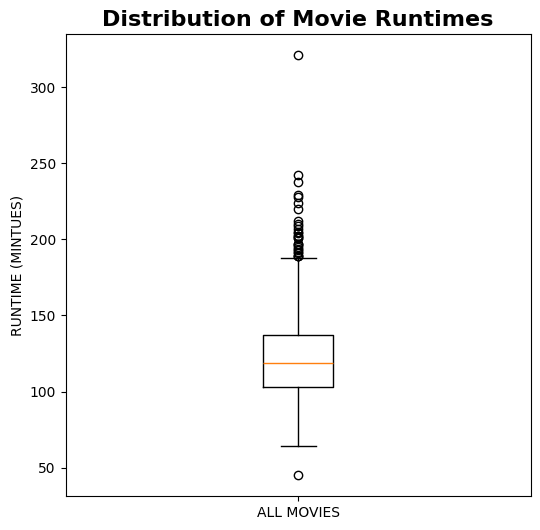

In [39]:
plt.figure(figsize=(6,6))
plt.boxplot(data['Runtime'])
plt.title('Distribution of Movie Runtimes',fontsize=16,fontweight='bold')
plt.ylabel('RUNTIME (MINTUES)')
plt.xticks([1],['ALL MOVIES'])
plt.show()

### Interpretation
By looking at the box plot, the orange line shows the median runtime is around 120 minutes (2 hours). The bulk of standard movies run between 100 and 140 minutes. The boundary line for a normal long movie stops at 190 minutes, and any movie longer than that is an outlier—with the most extreme case running over 320 minutes.

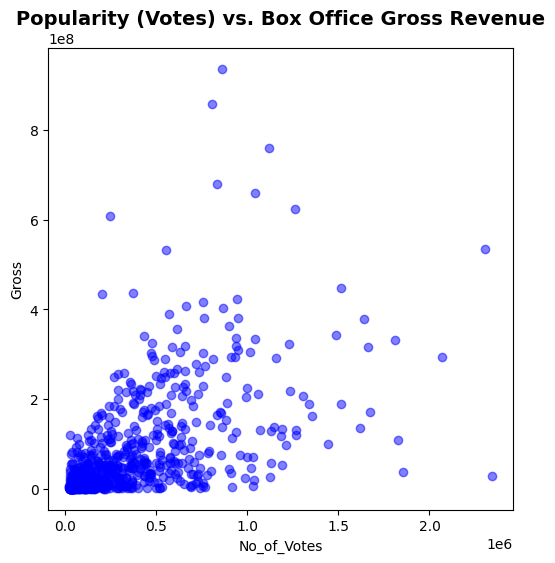

In [40]:
plt.figure(figsize=(6,6))
plt.scatter(data['No_of_Votes'],data['Gross'],alpha=0.5,color='blue')
plt.title('Popularity (Votes) vs. Box Office Gross Revenue', fontsize=14, fontweight='bold')
plt.xlabel('No_of_Votes')
plt.ylabel('Gross')
plt.show()

## Interpretation
The scatter plot displays an upward trend, indicating a positive relationship between the two variables. At the lower end, there is a dense cluster of points representing movies with lower popularity and lower gross collections. As we move upward, we can observe that as popularity increases, the gross collection generally increases as well.

However, there are a few notable exceptions. For instance, the points in the bottom-right corner represent movies with high popularity that failed to achieve high gross collections. Conversely, on the left side, there are movies with low popularity that managed to generate a surprisingly high gross collection.

In [41]:
top_directors=data.groupby('Director')['Gross'].sum().reset_index()
sorted_director=top_directors.sort_values(by='Gross',ascending=False).head(10)
print(sorted_director)

              Director         Gross
470   Steven Spielberg  2.478133e+09
36       Anthony Russo  2.205039e+09
83   Christopher Nolan  1.937454e+09
202      James Cameron  1.748237e+09
383      Peter Jackson  1.597312e+09
195        J.J. Abrams  1.423171e+09
58           Brad Bird  1.099628e+09
426    Robert Zemeckis  1.049446e+09
107        David Yates  9.789537e+08
380        Pete Docter  9.393821e+08


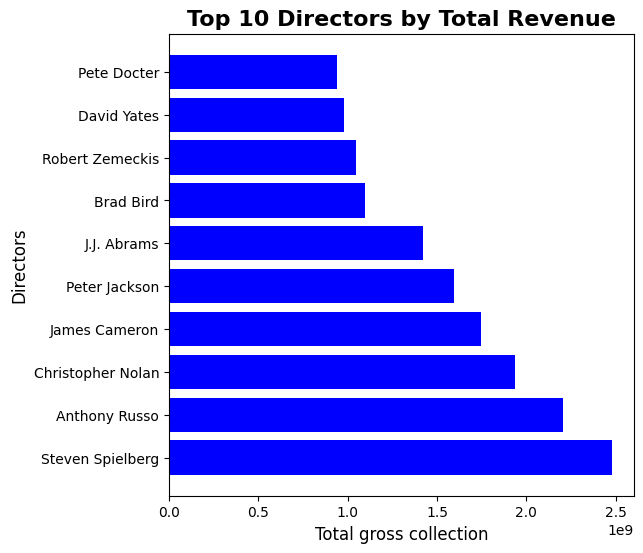

In [42]:
plt.figure(figsize=(6,6))
plt.barh(sorted_director['Director'],sorted_director['Gross'],color='blue')
plt.title('Top 10 Directors by Total Revenue',fontsize=16,fontweight='bold')
plt.xlabel('Total gross collection',fontsize=12)
plt.ylabel('Directors',fontsize=12)
plt.show()

## Interpretation
Steven Spielberg has the highest gross collection at the box office, whereas Pete Docter has the lowest gross collection.

# Conclusion

This notebook explored the IMDB Top 1000 Movies dataset to understand what patterns exist across directors, actors, genres, ratings, and box office performance.
Key findings from the analysis:

Most movies in this dataset run between 100 and 140 minutes, with a median runtime of around 120 minutes. Films exceeding 190 minutes are statistical outliers, suggesting the industry has a strong preference for the 2-hour format.
Popularity on IMDB measured by number of votes shows a generally positive relationship with gross collection — movies that attract more votes tend to earn more at the box office. However, exceptions exist on both ends, confirming that votes alone cannot predict commercial success.
Steven Spielberg leads among directors by total box office gross in this dataset, reflecting both the volume and commercial scale of his filmmaking across decades.
Drama is the most frequently occurring genre in this dataset after applying genre splitting, indicating that critically acclaimed films tend to lean toward dramatic storytelling.
The correlation between overview word count and IMDB rating is close to zero, meaning how long or short a movie's description is has no meaningful relationship with how it is rated.
Average ratings have remained relatively stable across decades, suggesting that the standard for what audiences and critics consider a top-rated film has not shifted dramatically over time.
The 2020s decade shows NaN for average gross collection because several recent films in the dataset have not yet reported their earnings — this is a data limitation, not a reflection of poor performance.

What this analysis does not tell us: this dataset contains only the top 1000 rated films, so all conclusions apply to critically acclaimed movies only and cannot be generalized to the entire film industry.